# Baseline Evaluation (Raw Softmax vs GT)

Compares raw per-scan softmax predictions (argmax) to GT labels directly — no BKI, no temporal fusion. Both sides are mapped to the common 11-class taxonomy.

Pipeline:
1. Softmax `.bin` → `(n_points, n_classes)` float16 → `argmax` → channel
2. `channel → learning_map_inv[channel]` (raw label in inferred dataset space)
3. `raw → {inferred_key}_to_common` → common class
4. GT `.bin` uint32 per point → `{gt_key}_to_common` → common class

In [1]:
import os
import glob
import numpy as np
import yaml
from sklearn.metrics import jaccard_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Configuration

In [ ]:
# Dataset paths
DATA_DIR = "/media/donceykong/doncey_ssd_011/datasets/"
DATASET_NAME = "mcd"
SEQUENCE_NAME = "kth_night_05"

SCAN_SUFFIX = "lidar_bin/data"
SOFTMAX_SUFFIX = "inferred_labels/cenet_kitti360_softmax"
GT_SUFFIX = "gt_labels_terrain"

# Restrict comparison to scans that have a corresponding .txt file in this
# evaluation directory (relative to the sequence dir). This ensures the
# baseline is computed on exactly the same scans that the BKI run evaluated.
EVAL_REF_SUFFIX = "evaluations/cross_domain/vanilla"

# Mapping keys: which *_to_common mapping to use for each side
INFERRED_KEY = "kitti360"  # softmax channels correspond to kitti360 raw labels
GT_KEY = "mcd"             # GT file labels are raw mcd labels

# labels_common.yaml location (relative to this notebook)
LABELS_COMMON_PATH = "../config/datasets/labels_common.yaml"
LABELS_INFERRED_PATH = "../config/datasets/labels_kitti360.yaml"  # for learning_map_inv

SEQUENCE_DIR = os.path.join(DATA_DIR, DATASET_NAME, SEQUENCE_NAME)
SCAN_DIR = os.path.join(SEQUENCE_DIR, SCAN_SUFFIX)
SOFTMAX_DIR = os.path.join(SEQUENCE_DIR, SOFTMAX_SUFFIX)
GT_DIR = os.path.join(SEQUENCE_DIR, GT_SUFFIX)
EVAL_REF_DIR = os.path.join(SEQUENCE_DIR, EVAL_REF_SUFFIX)

MAX_SCANS = None  # None = all

print(f"Scan dir:    {SCAN_DIR}")
print(f"Softmax dir: {SOFTMAX_DIR}")
print(f"GT dir:      {GT_DIR}")
print(f"Eval ref:    {EVAL_REF_DIR}")

Scan dir:    /media/donceykong/doncey_ssd_011/datasets/mcd/kth_day_09/lidar_bin/data
Softmax dir: /media/donceykong/doncey_ssd_011/datasets/mcd/kth_day_09/inferred_labels/cenet_kitti360_softmax
GT dir:      /media/donceykong/doncey_ssd_011/datasets/mcd/kth_day_09/gt_labels_terrain
Eval ref:    /media/donceykong/doncey_ssd_011/datasets/mcd/kth_day_09/evaluations/cross_domain/vanilla


## Load taxonomy + mapping tables

In [3]:
with open(LABELS_COMMON_PATH, "r") as f:
    common_cfg = yaml.safe_load(f)

NUM_CLASSES = int(common_cfg["num_class"])
COMMON_CLASSES = [common_cfg["labels"][i] for i in range(NUM_CLASSES)]

inferred_to_common = {int(k): int(v) for k, v in common_cfg[f"{INFERRED_KEY}_to_common"].items()}
gt_to_common       = {int(k): int(v) for k, v in common_cfg[f"{GT_KEY}_to_common"].items()}

with open(LABELS_INFERRED_PATH, "r") as f:
    inferred_cfg = yaml.safe_load(f)
learning_map_inv = {int(k): int(v) for k, v in inferred_cfg["learning_map_inv"].items()}

def build_lut(mapping, size):
    lut = np.zeros(size, dtype=np.int32)
    for k, v in mapping.items():
        if 0 <= k < size:
            lut[k] = v
    return lut

# Channel → common LUT (composes learning_map_inv then inferred_to_common)
max_ch = max(learning_map_inv.keys()) + 1
channel_to_common = np.zeros(max_ch, dtype=np.int32)
for ch, raw in learning_map_inv.items():
    channel_to_common[ch] = inferred_to_common.get(raw, 0)

# GT raw → common LUT (GT labels are uint32; size to cover max key, include 65535 sentinel)
gt_max = max(gt_to_common.keys()) + 1
gt_lut = build_lut(gt_to_common, max(gt_max, 65536))

print(f"num_class = {NUM_CLASSES}")
print(f"common classes: {COMMON_CLASSES}")
print(f"channel_to_common LUT size: {channel_to_common.shape}")
print(f"gt_lut size: {gt_lut.shape}")

num_class = 9
common classes: ['unlabeled', 'road', 'sidewalk', 'parking', 'building', 'fence', 'vegetation', 'vehicle', 'terrain']
channel_to_common LUT size: (45,)
gt_lut size: (65536,)


## Iterate over scans

In [4]:
# 1. Collect scan IDs from the evaluation reference directory.
eval_ref_files = sorted(glob.glob(os.path.join(EVAL_REF_DIR, "*.txt")))
ref_ids = [os.path.splitext(os.path.basename(p))[0] for p in eval_ref_files]
print(f"Found {len(ref_ids)} .txt files in {EVAL_REF_DIR}")

# 2. Verify every ref .txt has matching scan/softmax/gt .bin files.
ok_ids = []
missing_scan = []
missing_sm = []
missing_gt = []
for sid in ref_ids:
    scan_ok = os.path.exists(os.path.join(SCAN_DIR, sid + ".bin"))
    sm_ok   = os.path.exists(os.path.join(SOFTMAX_DIR, sid + ".bin"))
    gt_ok   = os.path.exists(os.path.join(GT_DIR, sid + ".bin"))
    if scan_ok and sm_ok and gt_ok:
        ok_ids.append(sid)
    else:
        if not scan_ok: missing_scan.append(sid)
        if not sm_ok:   missing_sm.append(sid)
        if not gt_ok:   missing_gt.append(sid)

print(f"Scans with all files present: {len(ok_ids)} / {len(ref_ids)}")
if missing_scan: print(f"  missing scan .bin:    {len(missing_scan)} (first: {missing_scan[:3]})")
if missing_sm:   print(f"  missing softmax .bin: {len(missing_sm)} (first: {missing_sm[:3]})")
if missing_gt:   print(f"  missing gt .bin:      {len(missing_gt)} (first: {missing_gt[:3]})")

assert len(ok_ids) > 0, "No scans to evaluate — check EVAL_REF_SUFFIX and data paths."

if MAX_SCANS is not None:
    ok_ids = ok_ids[:MAX_SCANS]
    print(f"Using first {len(ok_ids)} for evaluation")

# 3. Run baseline on the verified set.
gt_all = []
pred_all = []
skipped = 0

for scan_id in ok_ids:
    scan_path = os.path.join(SCAN_DIR, scan_id + ".bin")
    sm_path   = os.path.join(SOFTMAX_DIR, scan_id + ".bin")
    gt_path   = os.path.join(GT_DIR, scan_id + ".bin")

    # n_points from scan (float32 x 4 per point)
    scan_bytes = os.path.getsize(scan_path)
    n_points = scan_bytes // (4 * 4)
    if n_points == 0:
        skipped += 1
        continue

    # Softmax: float16, (n_points, n_classes)
    sm_bytes = os.path.getsize(sm_path)
    n_classes_file = sm_bytes // (2 * n_points)
    if n_classes_file * 2 * n_points != sm_bytes:
        print(f"[skip] {scan_id}: softmax size mismatch")
        skipped += 1
        continue
    softmax = np.fromfile(sm_path, dtype=np.float16).reshape(n_points, n_classes_file)
    pred_channel = np.argmax(softmax, axis=1).astype(np.int32)
    pred_channel = np.where(pred_channel < channel_to_common.shape[0], pred_channel, 0)
    pred_common = channel_to_common[pred_channel]

    # GT: uint32 per point
    gt_raw = np.fromfile(gt_path, dtype=np.uint32)
    if gt_raw.shape[0] != n_points:
        m = min(gt_raw.shape[0], n_points)
        gt_raw = gt_raw[:m]
        pred_common = pred_common[:m]
    gt_raw_clipped = np.where(gt_raw < gt_lut.shape[0], gt_raw, 0)
    gt_common = gt_lut[gt_raw_clipped]

    gt_all.append(gt_common)
    pred_all.append(pred_common)

gt_all = np.concatenate(gt_all)
pred_all = np.concatenate(pred_all)
print(f"Scans processed: {len(ok_ids) - skipped}  (skipped: {skipped})")
print(f"Total points: {len(gt_all)}")
print(f"Unique GT classes:   {np.unique(gt_all)}")
print(f"Unique pred classes: {np.unique(pred_all)}")

Found 4510 .txt files in /media/donceykong/doncey_ssd_011/datasets/mcd/kth_day_09/evaluations/cross_domain/vanilla
Scans with all files present: 4510 / 4510
Scans processed: 4510  (skipped: 0)
Total points: 295567360
Unique GT classes:   [0 1 2 3 4 5 6 7 8]
Unique pred classes: [0 1 2 3 4 5 6 7 8]


## Per-class metrics

In [5]:
mask = gt_all != 0
gt_eval = gt_all[mask]
pred_eval = pred_all[mask]
print(f"Points after removing unlabeled: {len(gt_eval)}")

semantic_classes = np.arange(1, NUM_CLASSES)
iou_scores = jaccard_score(gt_eval, pred_eval, labels=semantic_classes, average=None, zero_division=0)

per_class_acc = np.zeros(len(semantic_classes))
for i, cls_id in enumerate(semantic_classes):
    cls_mask = gt_eval == cls_id
    if cls_mask.sum() > 0:
        per_class_acc[i] = (pred_eval[cls_mask] == cls_id).sum() / cls_mask.sum()

per_class_prec = np.zeros(len(semantic_classes))
for i, cls_id in enumerate(semantic_classes):
    pred_mask = pred_eval == cls_id
    if pred_mask.sum() > 0:
        per_class_prec[i] = (gt_eval[pred_mask] == cls_id).sum() / pred_mask.sum()

print(f"\n{'Class':>3}  {'Name':<15s}  {'IoU':>8s}  {'Accuracy':>10s}  {'Precision':>10s}  {'GT count':>12s}  {'Pred count':>12s}")
print("-" * 86)
for i, cls_id in enumerate(semantic_classes):
    gt_count = int(np.sum(gt_eval == cls_id))
    pred_count = int(np.sum(pred_eval == cls_id))
    print(f"{cls_id:>3d}  {COMMON_CLASSES[cls_id]:<15s}  {iou_scores[i]:>8.4f}  {per_class_acc[i]:>10.4f}  {per_class_prec[i]:>10.4f}  {gt_count:>12d}  {pred_count:>12d}")

present_mask = np.array([np.sum(gt_eval == c) > 0 for c in semantic_classes])
miou = float(np.mean(iou_scores[present_mask])) if present_mask.any() else 0.0
mean_acc = float(np.mean(per_class_acc[present_mask])) if present_mask.any() else 0.0
mean_prec = float(np.mean(per_class_prec[present_mask])) if present_mask.any() else 0.0

print(f"\nmIoU (over {int(present_mask.sum())} present classes):       {miou:.4f}")
print(f"Mean accuracy (recall):                  {mean_acc:.4f}")
print(f"Mean precision:                          {mean_prec:.4f}")
print(f"Overall accuracy:                        {np.mean(gt_eval == pred_eval):.4f}")

Points after removing unlabeled: 247247602

Class  Name                  IoU    Accuracy   Precision      GT count    Pred count
--------------------------------------------------------------------------------------
  1  road               0.2427      0.6361      0.2818      23787448      53688210
  2  sidewalk           0.0365      0.0378      0.5084      49770064       3703711
  3  parking            0.0004      0.0008      0.0008       1038805       1016519
  4  building           0.7490      0.8705      0.8429      95102884      98215430
  5  fence              0.0328      0.1500      0.0403       1325848       4936480
  6  vegetation         0.4786      0.5417      0.8044      46311022      31187758
  7  vehicle            0.1907      0.3528      0.2933       6880602       8276728
  8  terrain            0.2849      0.3418      0.6310      23030929      12476306

mIoU (over 8 present classes):       0.2520
Mean accuracy (recall):                  0.3664
Mean precision:            

## Per-class bar chart

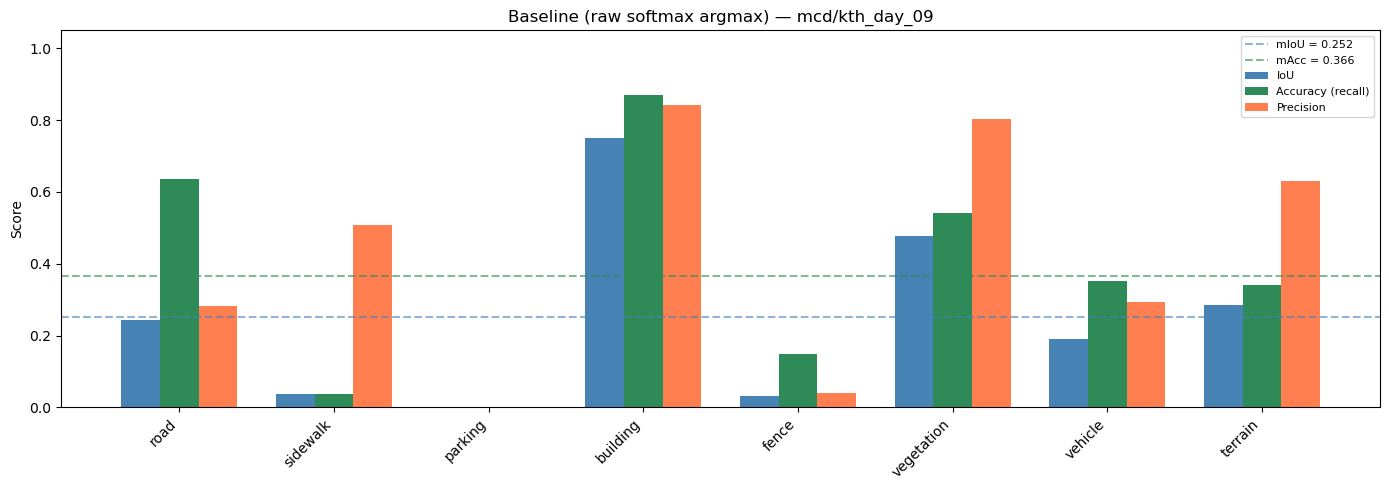

In [6]:
class_names = [COMMON_CLASSES[c] for c in semantic_classes]
x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, iou_scores, width, label="IoU", color="steelblue")
ax.bar(x,         per_class_acc, width, label="Accuracy (recall)", color="seagreen")
ax.bar(x + width, per_class_prec, width, label="Precision", color="coral")

ax.axhline(miou, color="steelblue", linestyle="--", alpha=0.6, label=f"mIoU = {miou:.3f}")
ax.axhline(mean_acc, color="seagreen", linestyle="--", alpha=0.6, label=f"mAcc = {mean_acc:.3f}")

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_title(f"Baseline (raw softmax argmax) — {DATASET_NAME}/{SEQUENCE_NAME}")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## Confusion matrix

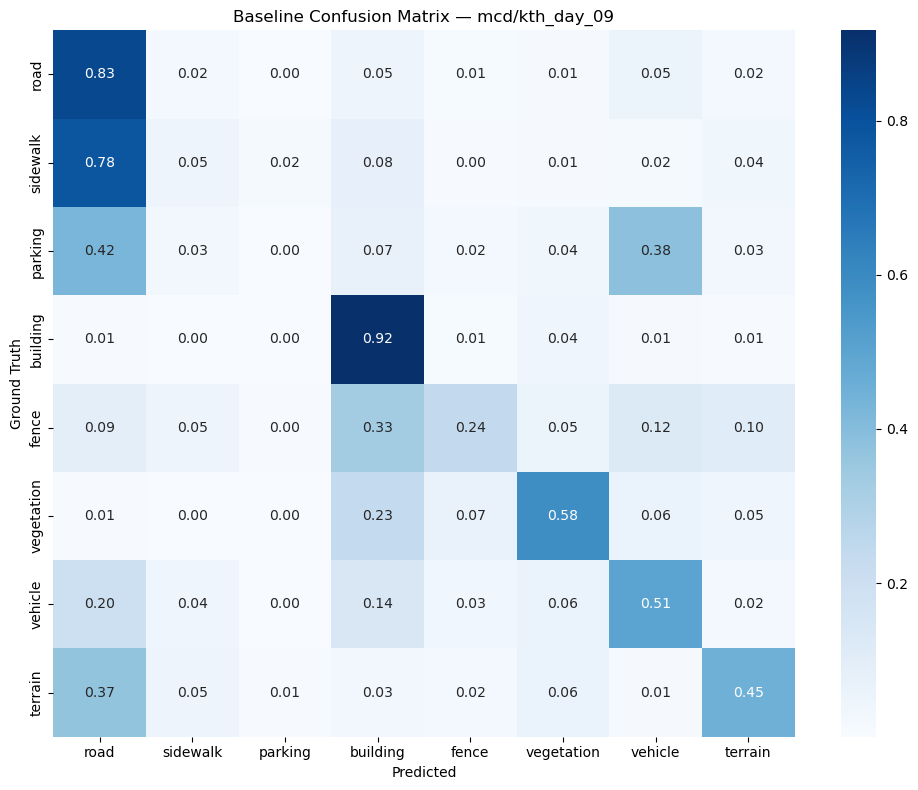

In [7]:
cm = confusion_matrix(gt_eval, pred_eval, labels=semantic_classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Ground Truth")
ax.set_title(f"Baseline Confusion Matrix — {DATASET_NAME}/{SEQUENCE_NAME}")
plt.tight_layout()
plt.show()